# Preparing the envirement

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import torch
import os
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

In [2]:
#Check the device compatibility

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: mps


# Load the models

In [3]:
#Load the Simple Model (Just CNN and clasificator whitout the new Clinical Vector)
model_path = "Models/Model_Exec_720_Epoch_150_cpu_portable.pth"

values = torch.load(model_path, map_location="cpu", weights_only=False)
simple_model = values["modelo"]

simple_model = simple_model.to(device)
simple_model.eval()

print("Modelo simple cargado correctamente")

Modelo simple cargado correctamente


In [4]:
print(simple_model)

CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(128, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(16, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): Conv2d(272, 8, ker

In [5]:

full_model = torch.export.load("Models/FineDentalDeepGANew60Fold.pt2")
print("Modelo .pt2 cargado correctamente")


Modelo .pt2 cargado correctamente


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1592.)
  tensor = torch.frombuffer(


In [6]:
print(full_model.graph_signature)


# inputs
p_embedding_extractor_features_0_0_weight: PARAMETER target='embedding_extractor.features.0.0.weight'
p_embedding_extractor_features_0_0_bias: PARAMETER target='embedding_extractor.features.0.0.bias'
p_embedding_extractor_features_0_1_weight: PARAMETER target='embedding_extractor.features.0.1.weight'
p_embedding_extractor_features_0_1_bias: PARAMETER target='embedding_extractor.features.0.1.bias'
p_embedding_extractor_features_1_0_weight: PARAMETER target='embedding_extractor.features.1.0.weight'
p_embedding_extractor_features_1_0_bias: PARAMETER target='embedding_extractor.features.1.0.bias'
p_embedding_extractor_features_1_1_weight: PARAMETER target='embedding_extractor.features.1.1.weight'
p_embedding_extractor_features_1_1_bias: PARAMETER target='embedding_extractor.features.1.1.bias'
p_embedding_extractor_features_2_0_weight: PARAMETER target='embedding_extractor.features.2.0.weight'
p_embedding_extractor_features_2_0_bias: PARAMETER target='embedding_extractor.features.

# Data loaders

In [7]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [8]:
#Test Data DeepGA Model Data Loader

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit

def build_test_loader(
    data_dir,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
):
    eval_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]), #TODO Check later how affects prediction
    ])

    ds_base = datasets.ImageFolder(root=data_dir, transform=None)
    y = np.array(ds_base.targets)
    idx = np.arange(len(ds_base))

    # Split estratificado: (train+val) vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # Split estratificado: train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    ds_eval = datasets.ImageFolder(root=data_dir, transform=eval_transform)

    pin = torch.cuda.is_available()

    test_dl = DataLoader(
        Subset(ds_eval, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin
    )

    return {
        "test_dl": test_dl,
        "ds_eval": ds_eval,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "class_names": ds_eval.classes,
        "class_to_idx": ds_eval.class_to_idx,
        "n_channels": 1,
        "n_classes": len(ds_eval.classes),
        "out_size": image_size,
    }

In [9]:
loader_info = build_test_loader(
    data_dir="DataSet/radiografia_dataset_original",
    image_size=128,
    batch_size=1,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0,
)

print(loader_info["class_names"])
print(loader_info["class_to_idx"])

['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica']
{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5}


In [10]:
# Data Loader for the Full DeepGA Model


# ------------------------------------------------------------
# Configuración base
# ------------------------------------------------------------

CSV_PATH = "DataSet/dataset_maestro.csv"
IMAGE_ROOT = "DataSet/radiografia_dataset_original"

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
}

idx_to_class = {v: k for k, v in class_to_idx.items()}

def normalize_image_key(external_id):
    external_id = str(external_id).strip()
    prefix = "radiografia_dataset_original/"

    if external_id.startswith(prefix):
        return external_id[len(prefix):]

    return external_id


def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)


def build_image_path_dict(root_dir):
    valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
    root_dir = Path(root_dir)

    return {
        normalize_image_key(str(path.relative_to(root_dir))): str(path)
        for path in sorted(root_dir.rglob("*"))
        if path.is_file() and path.suffix.lower() in valid_exts
    }


def build_samples(csv_path=CSV_PATH, image_root=IMAGE_ROOT):
    df = pd.read_csv(csv_path)
    image_path_dict = build_image_path_dict(image_root)

    samples = []
    errors = []

    for idx, row in df.iterrows():
        try:
            image_key = normalize_image_key(row["external_id"])

            if image_key not in image_path_dict:
                raise KeyError(f"No se encontró imagen para: {image_key}")

            if row["Clase"] not in class_to_idx:
                raise KeyError(f"Clase no válida: {row['Clase']}")

            samples.append({
                "image_key": image_key,
                "image_path": image_path_dict[image_key],
                "clinical_vector": build_clinical_vector(
                    dx_periapical=row["Dx Periapical"],
                    sensibilidad=row["Sensibilidad"],
                    percusion=row["Percusión"],
                    movilidad=row["Movilidad"],
                    palpacion=row["Palpación"],
                ),
                "label": class_to_idx[row["Clase"]],
            })

        except Exception as e:
            errors.append({
                "row_idx": idx,
                "id": row.get("id", None),
                "external_id": row.get("external_id", None),
                "clase": row.get("Clase", None),
                "error": str(e),
            })

    print("Número de imágenes indexadas:", len(image_path_dict))
    print("Samples válidos:", len(samples))
    print("Errores:", len(errors))

    for err in errors:
        print("=" * 80)
        print(f"Fila: {err['row_idx']}")
        print(f"id: {err['id']}")
        print(f"external_id: {err['external_id']}")
        print(f"Clase: {err['clase']}")
        print(f"Error: {err['error']}")

    return samples, errors, image_path_dict

In [11]:
class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [sample["label"] for sample in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        clinical = sample["clinical_vector"]
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [12]:
def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    indices = np.arange(len(y))

    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed,
    )

    trainval_idx, test_idx = next(sss_test.split(indices, y))

    y_trainval = y[trainval_idx]
    relative_val_split = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=relative_val_split,
        random_state=seed,
    )

    train_rel_idx, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel_idx]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [13]:
def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    generator = torch.Generator()
    generator.manual_seed(seed)

    pin_memory = torch.cuda.is_available()

    return {
        "train": DataLoader(
            Subset(ds, train_idx),
            batch_size=batch_size,
            shuffle=True,
            generator=generator,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
        "val": DataLoader(
            Subset(ds, val_idx),
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
        "test": DataLoader(
            Subset(ds, test_idx),
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=pin_memory,
        ),
    }

# Testing the DeepGA Model

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

def test_model_with_internal_loader(
    model,
    data_dir,
    device,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
    show_confusion_matrix=True,
):
    # -------------------------------------------------
    # 1) construir loader igual que en el notebook
    # -------------------------------------------------
    loader_info = build_test_loader(
        data_dir=data_dir,
        image_size=image_size,
        batch_size=batch_size,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
        num_workers=num_workers,
    )

    test_dl = loader_info["test_dl"]
    class_names = loader_info["class_names"]

    # -------------------------------------------------
    # 2) evaluación
    # -------------------------------------------------
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_dl:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)

    print("=== RESULTADOS EN TEST ===")
    print(f"Accuracy: {acc:.4f}\n")

    print("=== class_names ===")
    print(class_names)
    print()

    print("=== class_to_idx ===")
    print(loader_info["class_to_idx"])
    print()

    print("=== tamaño del split test ===")
    print(len(loader_info["test_idx"]))
    print()

    print("=== CLASIFICACIÓN POR CLASE ===")
    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(len(class_names))),
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(class_names)))
    )

    print("=== MATRIZ DE CONFUSIÓN ===")
    print(cm)

    if show_confusion_matrix:
        plt.figure(figsize=(8, 8))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
        plt.title("Matriz de confusión - Test")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "y_true": all_labels,
        "y_pred": all_preds,
        "confusion_matrix": cm,
        "class_names": class_names,
        "class_to_idx": loader_info["class_to_idx"],
        "test_idx": loader_info["test_idx"],
        "test_dl": test_dl,
        "ds_eval": loader_info["ds_eval"],
    }

=== RESULTADOS EN TEST ===
Accuracy: 0.4182

=== class_names ===
['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica']

=== class_to_idx ===
{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5}

=== tamaño del split test ===
55

=== CLASIFICACIÓN POR CLASE ===
                                    precision    recall  f1-score   support

                   Necrosis Pulpar     0.3333    0.2667    0.2963        15
              Previamente iniciado     0.0000    0.0000    0.0000         4
               Previamente tratado     0.3571    0.7143    0.4762         7
                      Pulpa Normal     0.8182    1.0000    0.9000         9
Pulpitis irreversible asintomatica     0.3333    0.3333    0.3333         9
 Pulpitis irreversible sintomatica     0.2222    0.1818

<Figure size 800x800 with 0 Axes>

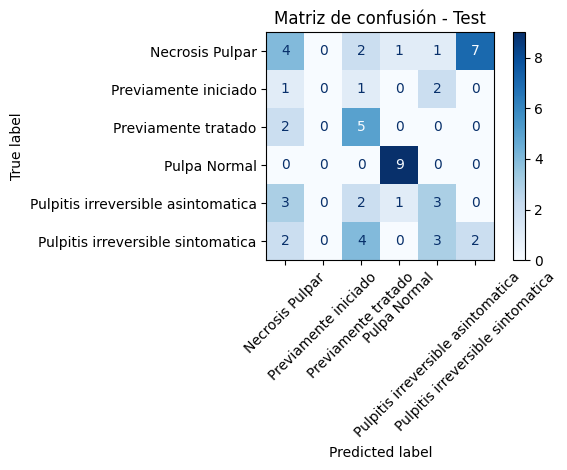

In [15]:
results_test = test_model_with_internal_loader(
    model=simple_model,
    data_dir=str("DataSet/radiografia_dataset_original"),   
    device=device,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
    show_confusion_matrix=True,
)

# Testing the DeepGA + Clinical Model

In [16]:
# Use the Data loader
samples, errors, image_path_dict = build_samples()

def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):


    dataset = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform,
    )

    splits = make_stratified_splits(
        targets=dataset.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=dataset,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": dataset,
        "loaders": loaders,
        "splits": splits,
    }



Número de imágenes indexadas: 361
Samples válidos: 359
Errores: 6
Fila: 61
id: 1. OD 34
external_id: Pulpitis reversible/1er OD 34.jpeg
Clase: Pulpitis Reversible
Error: 'No se encontró imagen para: Pulpitis reversible/1er OD 34.jpeg'
Fila: 62
id: 2. OD 36
external_id: Pulpitis reversible/2. OD 36.jpg
Clase: Pulpitis Reversible
Error: 'No se encontró imagen para: Pulpitis reversible/2. OD 36.jpg'
Fila: 63
id: 3. OD 46
external_id: Pulpitis reversible/3. OD 46.jpg
Clase: Pulpitis Reversible
Error: 'No se encontró imagen para: Pulpitis reversible/3. OD 46.jpg'
Fila: 64
id: 4. OD 21
external_id: Pulpitis reversible/4. OD 21.jpg
Clase: Pulpitis Reversible
Error: 'No se encontró imagen para: Pulpitis reversible/4. OD 21.jpg'
Fila: 65
id: 5. OD 24
external_id: Pulpitis reversible/5. OD 24.jpg
Clase: Pulpitis Reversible
Error: 'No se encontró imagen para: Pulpitis reversible/5. OD 24.jpg'
Fila: 321
id: 26. OD 21
external_id: Previamente iniciado/26. OD 21.jpg
Clase: Previamente iniciado
Error

In [17]:
@torch.no_grad()
def evaluate_full_model(model, loader, device, idx_to_class):

    y_true = []
    y_pred = []

    for images, clinical, labels in loader:
        images = images.to(device)
        clinical = clinical.to(device)
        labels = labels.to(device)

        logits = model(images, clinical)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels_sorted = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels_sorted]

    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
    }

In [18]:
#Show confusion matrix

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()



=== Evaluación del modelo nuevo sobre TODO el dataset ===
Accuracy           : 0.6111
Precision macro    : 0.6042
Recall macro       : 0.5588
F1 macro           : 0.5670
Precision weighted : 0.6093
Recall weighted    : 0.6111
F1 weighted        : 0.5993

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.50      0.67      0.57        15
              Previamente iniciado       0.50      0.25      0.33         4
               Previamente Tratado       0.50      0.29      0.36         7
                      Pulpa Normal       0.80      0.89      0.84         9
Pulpitis Irreversible Asintomática       0.62      0.62      0.62         8
 Pulpitis Irreversible Sintomática       0.70      0.64      0.67        11

                          accuracy                           0.61        54
                         macro avg       0.60      0.56      0.57        54
                      weighted avg 

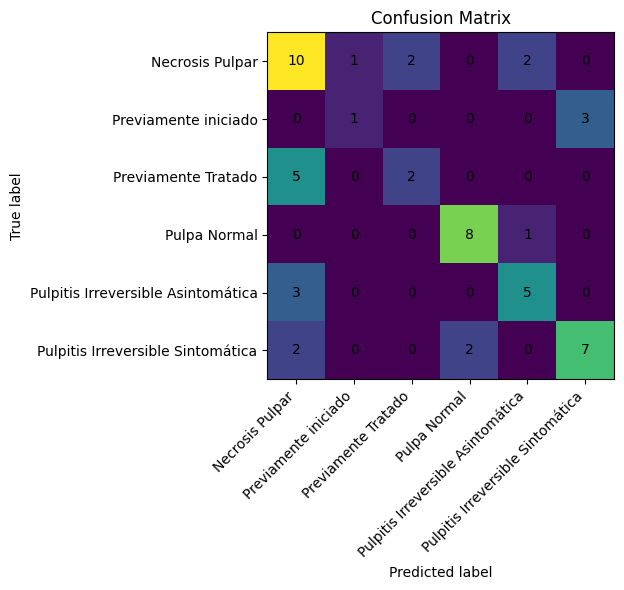

In [19]:
#Evaluation of the DeeGA + Clinical Vector Model
data_loader = load_data_module(samples, num_workers=0, batch_size=1)


exported_program = full_model
full_model_pt2 = exported_program.module().to(device)

results_new = evaluate_full_model(
    model=full_model_pt2,
    loader=data_loader["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print("=== Evaluación del modelo nuevo sobre TODO el dataset ===")
print(f"Accuracy           : {results_new['accuracy']:.4f}")
print(f"Precision macro    : {results_new['precision_macro']:.4f}")
print(f"Recall macro       : {results_new['recall_macro']:.4f}")
print(f"F1 macro           : {results_new['f1_macro']:.4f}")
print(f"Precision weighted : {results_new['precision_weighted']:.4f}")
print(f"Recall weighted    : {results_new['recall_weighted']:.4f}")
print(f"F1 weighted        : {results_new['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results_new["classification_report"])

print("\nConfusion matrix:\n")
print(results_new["confusion_matrix"])

plot_confusion_matrix(results_new["confusion_matrix"], idx_to_class)

# Individual Tests of the Models

In [20]:
simple_idx_to_class = {
    0: "Necrosis Pulpar",
    1: "Previamente iniciado",
    2: "Previamente tratado",
    3: "Pulpa Normal",
    4: "Pulpitis irreversible asintomatica",
    5: "Pulpitis irreversible sintomatica",
}

In [21]:
import unicodedata

def normalize_text_for_compare(text):
    text = str(text).strip()
    text = unicodedata.normalize("NFD", text)
    text = "".join(
        char for char in text
        if unicodedata.category(char) != "Mn"
    )
    return text.lower()

In [22]:
def predict_simple_model_from_ds_index(
    model,
    ds_eval,
    ds_index,
    device,
):
    model.eval()

    image_tensor, true_label = ds_eval[ds_index]

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)

        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    idx_to_class_simple = {v: k for k, v in ds_eval.class_to_idx.items()}

    image_path = ds_eval.samples[ds_index][0]

    return {
        "image_path": image_path,
        "true_idx": true_label,
        "true_class": idx_to_class_simple[true_label],
        "pred_idx": pred_idx,
        "pred_class": idx_to_class_simple[pred_idx],
        "confidence": confidence,
        "probs": probs.squeeze(0).cpu(),
    }

In [23]:
#Test individual prediction with the simple model

import random

ds_eval = results_test["ds_eval"]
test_idx = results_test["test_idx"]

ds_index = random.choice(test_idx)

simple_result = predict_simple_model_from_ds_index(
    model=simple_model,
    ds_eval=ds_eval,
    ds_index=ds_index,
    device=device,
)

print("Dataset index:", ds_index)
print("Imagen:", simple_result["image_path"])
print("Clase real:", simple_result["true_class"])
print("Predicción:", simple_result["pred_class"])
print("Confianza:", f"{simple_result['confidence']:.4f}")

print("\nProbabilidades:")
for i, class_name in enumerate(results_test["class_names"]):
    print(f"{class_name:45s}: {simple_result['probs'][i].item():.4f}")

    test_position = list(results_test["test_idx"]).index(ds_index)

batch_true = results_test["y_true"][test_position]
batch_pred = results_test["y_pred"][test_position]

class_names = results_test["class_names"]

print("=== Validación contra evaluación por batch ===")
print("Clase real batch:", class_names[batch_true])
print("Predicción batch:", class_names[batch_pred])

print("\n=== Predicción individual ===")
print("Clase real individual:", simple_result["true_class"])
print("Predicción individual:", simple_result["pred_class"])

Dataset index: 222
Imagen: DataSet/radiografia_dataset_original/Pulpa Normal/59. OD 35.jpg
Clase real: Pulpa Normal
Predicción: Pulpa Normal
Confianza: 0.9986

Probabilidades:
Necrosis Pulpar                              : 0.0000
Previamente iniciado                         : 0.0000
Previamente tratado                          : 0.0003
Pulpa Normal                                 : 0.9986
Pulpitis irreversible asintomatica           : 0.0001
Pulpitis irreversible sintomatica            : 0.0009
=== Validación contra evaluación por batch ===
Clase real batch: Pulpa Normal
Predicción batch: Pulpa Normal

=== Predicción individual ===
Clase real individual: Pulpa Normal
Predicción individual: Pulpa Normal


In [24]:
def predict_full_model_from_image_and_clinical(
    model,
    image_path,
    clinical_vector,
    transform,
    device,
    idx_to_class,
):
    try:
        model.eval()
    except NotImplementedError:
        pass

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    if not torch.is_tensor(clinical_vector):
        clinical_vector = torch.tensor(clinical_vector, dtype=torch.float32)

    clinical_tensor = clinical_vector.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor, clinical_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()
        confidence = probs[0, pred_idx].item()

    return {
        "pred_idx": pred_idx,
        "pred_class": idx_to_class[pred_idx],
        "confidence": confidence,
        "probs": probs.squeeze(0).cpu(),
    }

In [25]:
def print_prediction_result(title, result, idx_to_class):

    print("=" * 80)

    print(title)

    print("=" * 80)

    print(f"Predicción : {result['pred_class']}")

    print(f"Índice     : {result['pred_idx']}")

    print(f"Confianza  : {result['confidence']:.4f}")

    print()

    print("Probabilidades por clase:")

    for idx in sorted(idx_to_class.keys()):

        print(f"{idx_to_class[idx]:45s}: {result['probs'][idx].item():.4f}")

    print()

In [26]:
#Load a sample 

sample_idx = 213
sample = samples[sample_idx]

image_path = sample["image_path"]
clinical_vector = sample["clinical_vector"]
true_label = sample["label"]

print("Imagen:", image_path)
print("Clase real:", idx_to_class[true_label])
print("Vector clínico shape:", clinical_vector.shape)
print("Vector clínico:", clinical_vector)

Imagen: DataSet/radiografia_dataset_original/Necrosis Pulpar/23. OD 16.jpg
Clase real: Necrosis Pulpar
Vector clínico shape: torch.Size([11])
Vector clínico: tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.])


In [27]:
#Test prediction with the full model

full_result = predict_full_model_from_image_and_clinical(
    model=full_model_pt2,
    image_path=image_path,
    clinical_vector=clinical_vector,
    transform=transform,
    device=device,
    idx_to_class=idx_to_class,
)

print("Clase real:", idx_to_class[true_label])
print()

print_prediction_result(
    title="Modelo nuevo: DeepGA + vector clínico",
    result=full_result,
    idx_to_class=idx_to_class,
)

Clase real: Necrosis Pulpar

Modelo nuevo: DeepGA + vector clínico
Predicción : Necrosis Pulpar
Índice     : 0
Confianza  : 0.7704

Probabilidades por clase:
Necrosis Pulpar                              : 0.7704
Previamente iniciado                         : 0.0459
Previamente Tratado                          : 0.1132
Pulpa Normal                                 : 0.0020
Pulpitis Irreversible Asintomática           : 0.0577
Pulpitis Irreversible Sintomática            : 0.0107



# Compare the 2 Models

In [28]:
from pathlib import Path
import random


def normalize_path_for_match(path):
    return str(Path(path)).replace("\\", "/").lower()


def find_sample_idx_by_image_path(samples, image_path):
    target = normalize_path_for_match(image_path)

    for i, sample in enumerate(samples):
        sample_path = normalize_path_for_match(sample["image_path"])

        if sample_path == target:
            return i

    raise ValueError(f"No se encontró esa imagen en samples: {image_path}")

In [29]:
ds_eval = results_test["ds_eval"]
test_idx = results_test["test_idx"]

ds_index = random.choice(test_idx)

simple_image_path = ds_eval.samples[ds_index][0]
sample_idx = find_sample_idx_by_image_path(samples, simple_image_path)

sample = samples[sample_idx]

print("ds_index ImageFolder:", ds_index)
print("sample_idx samples:", sample_idx)
print("ImageFolder path:", simple_image_path)
print("samples path:", sample["image_path"])
print("Clase real ImageFolder:", ds_eval.classes[ds_eval.samples[ds_index][1]])
print("Clase real samples:", idx_to_class[sample["label"]])

ds_index ImageFolder: 71
sample_idx samples: 263
ImageFolder path: DataSet/radiografia_dataset_original/Necrosis Pulpar/73. OD47 .jpg
samples path: DataSet/radiografia_dataset_original/Necrosis Pulpar/73. OD47 .jpg
Clase real ImageFolder: Necrosis Pulpar
Clase real samples: Necrosis Pulpar


In [30]:
import matplotlib.pyplot as plt
from PIL import Image


def show_individual_prediction_comparison(
    image_path,
    true_label,
    simple_result,
    full_result,
    idx_to_class,
    title="Comparación de predicciones",
):
    true_class = idx_to_class[true_label]

    
    simple_ok = (
        normalize_text_for_compare(simple_result["pred_class"])
        == normalize_text_for_compare(true_class)
    )

    full_ok = (
        normalize_text_for_compare(full_result["pred_class"])
        == normalize_text_for_compare(true_class)
    )

    simple_mark = "✓" if simple_ok else "✗"
    full_mark = "✓" if full_ok else "✗"

    image = Image.open(image_path).convert("RGB")

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
        gridspec_kw={"width_ratios": [1.1, 1.4]},
    )
    axes[0].imshow(image, cmap="gray")
    axes[0].axis("off")
    axes[0].set_title("Imagen evaluada", fontsize=13)
    axes[1].axis("off")
    axes[1].set_title(title, fontsize=14, fontweight="bold", pad=12)

    text = (
        f"Clase real:\n"
        f"{true_class}\n\n"
        f"Modelo anterior: DeepGA solo imagen\n"
        f"Predicción: {simple_result['pred_class']}  {simple_mark}\n"
        f"Confianza : {simple_result['confidence']:.4f}\n\n"
        f"Modelo nuevo: DeepGA + vector clínico\n"
        f"Predicción: {full_result['pred_class']}  {full_mark}\n"
        f"Confianza : {full_result['confidence']:.4f}"
    )

    axes[1].text(
        0.02,
        0.95,
        text,
        va="top",
        ha="left",
        fontsize=12,
        linespacing=1.5,
        family="monospace",
    )

    plt.tight_layout()
    plt.show()

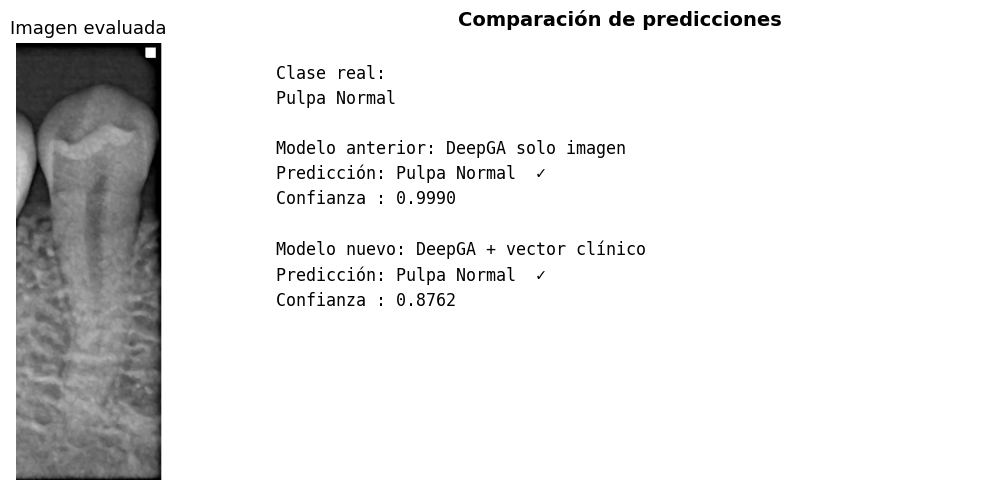

In [41]:


simple_result = predict_simple_model_from_ds_index(
    model=simple_model,
    ds_eval=ds_eval,
    ds_index=ds_index,
    device=device,
)

full_result = predict_full_model_from_image_and_clinical(
    model=full_model_pt2,
    image_path=sample["image_path"],
    clinical_vector=sample["clinical_vector"],
    transform=transform,
    device=device,
    idx_to_class=idx_to_class,
)

show_individual_prediction_comparison(
    image_path=sample["image_path"],
    true_label=sample["label"],
    simple_result=simple_result,
    full_result=full_result,
    idx_to_class=idx_to_class,
)

ds_index ImageFolder: 323
sample_idx samples: 103
ImageFolder path: DataSet/radiografia_dataset_original/Pulpitis irreversible sintomatica/43. OD16 .jpg
samples path: DataSet/radiografia_dataset_original/Pulpitis irreversible sintomatica/43. OD16 .jpg
Misma imagen: True
Clase real ImageFolder: Pulpitis irreversible sintomatica
Clase real samples: Pulpitis Irreversible Sintomática


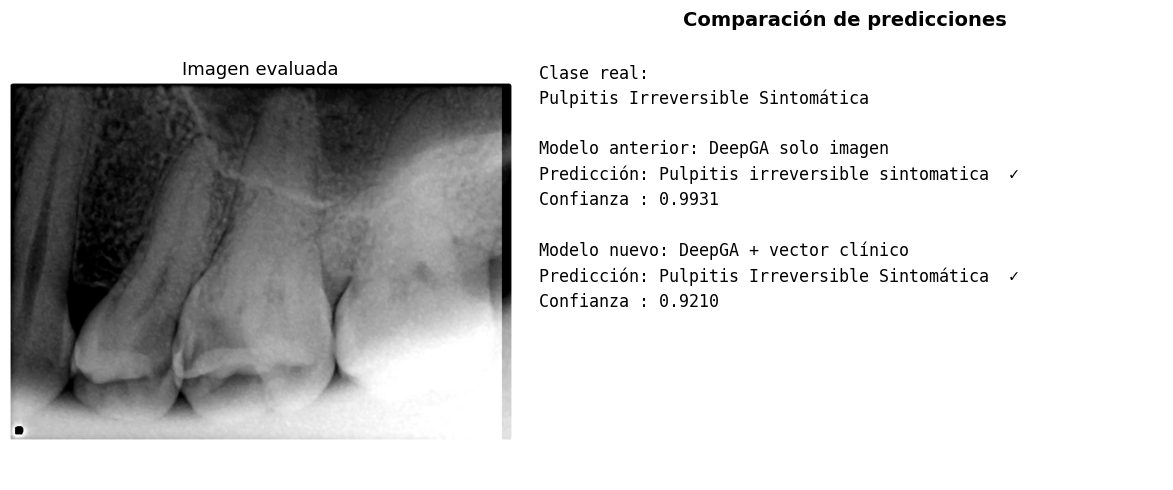

In [81]:
# ------------------------------------------------------------
# Predict a new random test image with both pipelines
# ------------------------------------------------------------

import random

ds_eval = results_test["ds_eval"]
test_idx = results_test["test_idx"]

# 1) Pick a new random image from the simple model test split
ds_index = random.choice(test_idx)

# 2) Get that image path from ImageFolder
simple_image_path = ds_eval.samples[ds_index][0]

# 3) Find the same image inside samples
sample_idx = find_sample_idx_by_image_path(samples, simple_image_path)
sample = samples[sample_idx]

print("ds_index ImageFolder:", ds_index)
print("sample_idx samples:", sample_idx)
print("ImageFolder path:", simple_image_path)
print("samples path:", sample["image_path"])
print("Misma imagen:", normalize_path_for_match(simple_image_path) == normalize_path_for_match(sample["image_path"]))
print("Clase real ImageFolder:", ds_eval.classes[ds_eval.samples[ds_index][1]])
print("Clase real samples:", idx_to_class[sample["label"]])

# 4) Predict with the simple model using ImageFolder pipeline
simple_result = predict_simple_model_from_ds_index(
    model=simple_model,
    ds_eval=ds_eval,
    ds_index=ds_index,
    device=device,
)

# 5) Predict with the full model using samples pipeline
full_result = predict_full_model_from_image_and_clinical(
    model=full_model_pt2,
    image_path=sample["image_path"],
    clinical_vector=sample["clinical_vector"],
    transform=transform,
    device=device,
    idx_to_class=idx_to_class,
)

# 6) Show comparison
show_individual_prediction_comparison(
    image_path=sample["image_path"],
    true_label=sample["label"],
    simple_result=simple_result,
    full_result=full_result,
    idx_to_class=idx_to_class,
)

# Experimental Test For Just Tests Results

In [33]:
def build_test_path_to_ds_index(ds_eval, test_idx):
    path_to_ds_index = {}

    for ds_index in test_idx:
        image_path = ds_eval.samples[ds_index][0]
        key = normalize_path_for_match(image_path)
        path_to_ds_index[key] = ds_index

    return path_to_ds_index


def build_test_path_to_sample_idx(samples, test_idx):
    path_to_sample_idx = {}

    for sample_idx in test_idx:
        image_path = samples[sample_idx]["image_path"]
        key = normalize_path_for_match(image_path)
        path_to_sample_idx[key] = sample_idx

    return path_to_sample_idx


def build_common_test_cases(ds_eval, simple_test_idx, samples, full_test_idx):
    simple_paths = build_test_path_to_ds_index(ds_eval, simple_test_idx)
    full_paths = build_test_path_to_sample_idx(samples, full_test_idx)

    common_keys = sorted(set(simple_paths.keys()) & set(full_paths.keys()))

    common_cases = []

    for key in common_keys:
        common_cases.append({
            "path_key": key,
            "ds_index": simple_paths[key],
            "sample_idx": full_paths[key],
        })

    return common_cases

In [34]:
data_module = load_data_module(
    samples,
    batch_size=1,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0,
)

full_splits = data_module["splits"]
full_dataset = data_module["dataset"]

In [35]:
common_test_cases = build_common_test_cases(
    ds_eval=results_test["ds_eval"],
    simple_test_idx=results_test["test_idx"],
    samples=samples,
    full_test_idx=full_splits["test_idx"],
)

print("Imágenes en test del modelo simple:", len(results_test["test_idx"]))
print("Imágenes en test del modelo nuevo:", len(full_splits["test_idx"]))
print("Intersección de ambos test:", len(common_test_cases))

Imágenes en test del modelo simple: 55
Imágenes en test del modelo nuevo: 54
Intersección de ambos test: 14


ds_index ImageFolder: 118
sample_idx samples: 293
ImageFolder path: DataSet/radiografia_dataset_original/Previamente iniciado/3. OD 34.jpg
samples path: DataSet/radiografia_dataset_original/Previamente iniciado/3. OD 34.jpg
Misma imagen: True
Clase real ImageFolder: Previamente iniciado
Clase real samples: Previamente iniciado


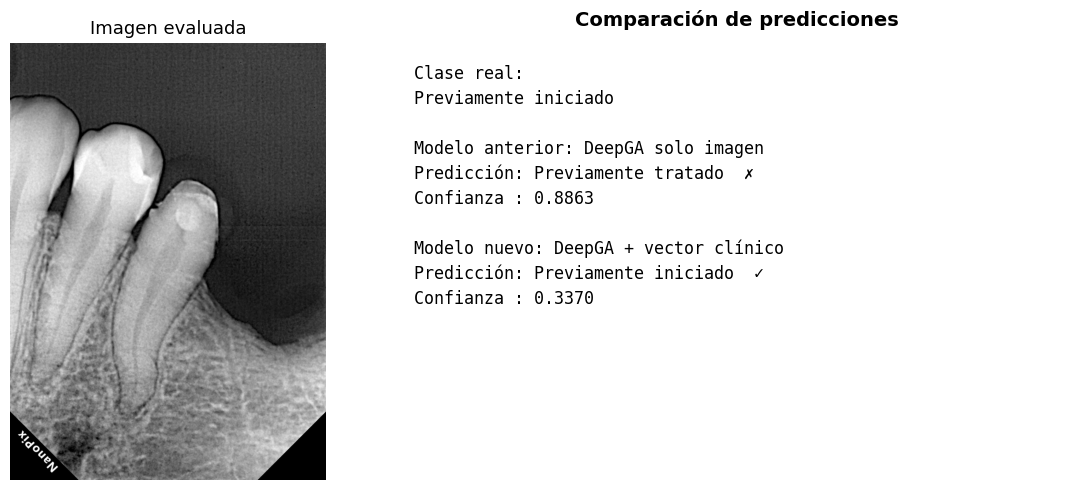

In [104]:
import random

if len(common_test_cases) == 0:
    raise ValueError("No hay imágenes en común entre ambos test sets.")

case = random.choice(common_test_cases)

ds_eval = results_test["ds_eval"]
ds_index = case["ds_index"]
sample_idx = case["sample_idx"]

sample = samples[sample_idx]

simple_image_path = ds_eval.samples[ds_index][0]
full_image_path = sample["image_path"]

print("ds_index ImageFolder:", ds_index)
print("sample_idx samples:", sample_idx)
print("ImageFolder path:", simple_image_path)
print("samples path:", full_image_path)
print("Misma imagen:", normalize_path_for_match(simple_image_path) == normalize_path_for_match(full_image_path))
print("Clase real ImageFolder:", ds_eval.classes[ds_eval.samples[ds_index][1]])
print("Clase real samples:", idx_to_class[sample["label"]])

simple_result = predict_simple_model_from_ds_index(
    model=simple_model,
    ds_eval=ds_eval,
    ds_index=ds_index,
    device=device,
)

full_result = predict_full_model_from_image_and_clinical(
    model=full_model_pt2,
    image_path=sample["image_path"],
    clinical_vector=sample["clinical_vector"],
    transform=transform,
    device=device,
    idx_to_class=idx_to_class,
)

show_individual_prediction_comparison(
    image_path=sample["image_path"],
    true_label=sample["label"],
    simple_result=simple_result,
    full_result=full_result,
    idx_to_class=idx_to_class,
)

# Delete this, just want to save something

In [83]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [84]:
results = evaluate_classification_model(
   #model=train_full_model,
    model=full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

AttributeError: 'ExportedProgram' object has no attribute 'eval'

In [87]:
import torch
from pathlib import Path
from datetime import datetime

save_dir = Path("saved_models")
save_dir.mkdir(exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"FineDentalDeepGANew60Fold_RECOVERED_{timestamp}"
checkpoint_path = save_dir / f"{model_name}.pth"

# Como full_model.state_dict ya es un dict, NO lleva paréntesis
model_state = {
    k: v.detach().cpu() if torch.is_tensor(v) else v
    for k, v in full_model.state_dict.items()
}

checkpoint = {
    "model_state_dict": model_state,
}

if "class_to_idx" in globals():
    checkpoint["class_to_idx"] = class_to_idx

if "idx_to_class" in globals():
    checkpoint["idx_to_class"] = idx_to_class

if "results" in globals():
    checkpoint["metrics"] = {
        "accuracy": results.get("accuracy"),
        "precision_macro": results.get("precision_macro"),
        "recall_macro": results.get("recall_macro"),
        "f1_macro": results.get("f1_macro"),
        "precision_weighted": results.get("precision_weighted"),
        "recall_weighted": results.get("recall_weighted"),
        "f1_weighted": results.get("f1_weighted"),
    }

torch.save(checkpoint, checkpoint_path)

print(f"Checkpoint recuperado y guardado en: {checkpoint_path}")

Checkpoint recuperado y guardado en: saved_models/FineDentalDeepGANew60Fold_RECOVERED_20260526_142124.pth


In [89]:
from pathlib import Path
import torch
from datetime import datetime

export_dir = Path("Models")
export_dir.mkdir(parents=True, exist_ok=True)

model_name = "FineDentalDeepGANew60Fold_RECOVERED"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

export_path = export_dir / f"{model_name}_{timestamp}.pt2"

torch.export.save(
    full_model,
    str(export_path),
)

print(f"ExportedProgram recuperado y guardado correctamente en: {export_path}")

ExportedProgram recuperado y guardado correctamente en: Models/FineDentalDeepGANew60Fold_RECOVERED_20260526_142247.pt2
